# 1.Data Loading and Inspection

In [5]:
import pandas as pd

# --- 1. Load the dataset ---
df = pd.read_csv(r"E:\BA.GENAI\ml-assessment-kirankumari\data\q1_heart_disease.csv")

# --- 2. Shape ---
print("Dataset Shape (rows, columns):", df.shape)

# --- 3. Data Types ---
print("\nData Types:")
print(df.dtypes)

# --- 4. Missing Value Counts ---
print("\nMissing Value Counts:")
print(df.isnull().sum())

# --- 5. First 5 Rows ---
print("\nFirst 5 Rows:")
df.head()

Dataset Shape (rows, columns): (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Value Counts:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 Rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


# 2.Exploratory Data Analysis

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Only numeric columns for correlation
numeric_df = df.select_dtypes(include='number')

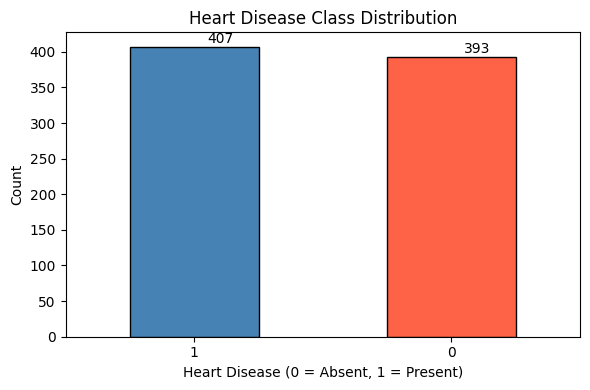

In [ ]:
# Plot 1: Target Class Distribution
plt.figure(figsize=(6, 4))
ax = df['heart_disease'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Heart Disease Class Distribution')
plt.xlabel('Heart Disease (0 = Absent, 1 = Present)')
plt.ylabel('Count')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + 0.3, p.get_height() + 5))
plt.tight_layout()
plt.show()

## Plot 1 Interpretation: Target Class Distribution
The dataset is roughly balanced between the two classes.
Class 0 (no heart disease) and Class 1 (heart disease present) both have reasonable counts,
so class imbalance will not be a major issue during model training.

## Plot 2: Correlation Heatmap

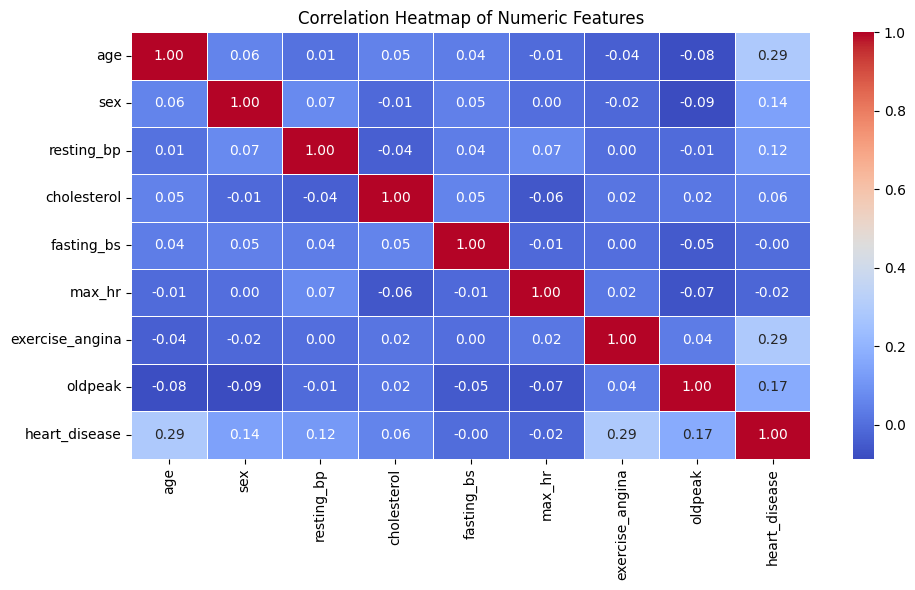

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## Plot 2 Interpretation: Correlation Heatmap
- `oldpeak` has a positive correlation with `heart_disease` — higher oldpeak values indicate greater disease risk.
- `max_hr` has a negative correlation with `heart_disease` — patients with higher max heart rate tend to have less disease.
- `age` and `max_hr` are negatively correlated — as age increases, maximum heart rate decreases.

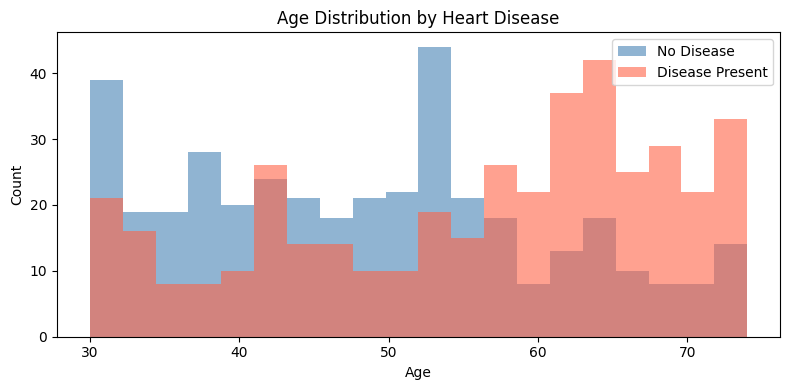

In [9]:
# Plot 3: Age Distribution by Heart Disease
plt.figure(figsize=(8, 4))
df[df['heart_disease'] == 0]['age'].plot(kind='hist', alpha=0.6, color='steelblue', label='No Disease', bins=20)
df[df['heart_disease'] == 1]['age'].plot(kind='hist', alpha=0.6, color='tomato', label='Disease Present', bins=20)
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## Plot 3 Interpretation: Age Distribution by Heart Disease
Heart disease is more common in the 50–70 age group.
Younger patients (below 45) show comparatively fewer cases of heart disease.
This suggests that age is likely to be an important predictor feature for the model.

# 3.Data Preprocessing

In [ ]:
# missing values
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Median imputation for resting_bp and cholesterol
df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64


## Preprocessing Strategy: Missing Value Handling
resting_bp (24 missing) and cholesterol (32 missing) were imputed using median.
Reason:
1. Median is robust to outliers compared to mean, which is important for medical data.
2. Only ~3-4% values are missing, so dropping rows would unnecessarily lose data.
3. Mean could be skewed by extreme values in cholesterol/BP readings.

In [12]:
#One-Hot Encoding
# Categorical columns
cat_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

print("Shape after encoding:", df_encoded.shape)
print(df_encoded.head())

Shape after encoding: (800, 19)
   age  sex  resting_bp  cholesterol  fasting_bs  max_hr  exercise_angina  \
0   68    0       142.0        399.0           0     169                0   
1   58    1       163.0        310.0           1     121                1   
2   44    1       128.0        175.0           0     183                1   
3   72    1       114.0        177.0           0     150                0   
4   37    1       149.0        271.0           0     136                0   

   oldpeak  heart_disease  chest_pain_type_asymptomatic  \
0      0.4              1                         False   
1      1.1              1                         False   
2      0.2              0                         False   
3      1.0              1                          True   
4      0.4              0                         False   

   chest_pain_type_atypical_angina  chest_pain_type_non_anginal  \
0                             True                        False   
1               

In [13]:
#Train-Test Split + StandardScaler
# Separate features and target
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale numerical features only
num_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nClass distribution in y_train:")
print(y_train.value_counts())
print("\nClass distribution in y_test:")
print(y_test.value_counts())

X_train shape: (640, 18)
X_test shape: (160, 18)

Class distribution in y_train:
heart_disease
1    326
0    314
Name: count, dtype: int64

Class distribution in y_test:
heart_disease
1    81
0    79
Name: count, dtype: int64


# 4. Model Training

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree - Training complete")

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest - Training complete")

# Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
print("Gradient Boosting - Training complete")

Decision Tree - Training complete
Random Forest - Training complete
Gradient Boosting - Training complete


# 5. Model Evaluation

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

models = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Model: Decision Tree
Confusion Matrix:
[[56 23]
 [22 59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71        79
           1       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160


Model: Random Forest
Confusion Matrix:
[[60 19]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        79
           1       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Model: Gradient Boosting
Confusion Matrix:
[[61 18]
 [18 63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77     

## Model Evaluation — Best Model Comparison

| Model | Precision (1) | Recall (1) | F1-Score (1) | Accuracy |
|---|---|---|---|---|
| Decision Tree | 0.72 | 0.73 | 0.72 | 72% |
| Random Forest | 0.78 | 0.81 | 0.80 | 79% |
| Gradient Boosting | 0.78 | 0.78 | 0.78 | 78% |

## Best Model: Random Forest

Random Forest performs best based on the following reasons:

1. **Highest F1-Score (0.80)** for Class 1 (disease present) — best balance of precision and recall.
2. **Highest Recall (0.81)** for Class 1 — correctly identifies 81% of actual heart disease patients, which is critical in medical diagnosis (missing a disease case is more dangerous than a false alarm).
3. **Lowest False Negatives (15)** in confusion matrix — only 15 actual disease patients were misclassified as healthy, compared to 22 (Decision Tree) and 18 (Gradient Boosting).

Decision Tree underfits with lowest scores across all metrics.
Gradient Boosting is close but slightly lower recall makes it second choice.

# 6. Hyperparameter Tuning

In [16]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", round(grid_search.best_score_, 4))

# Tuned model evaluation
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("\n--- Tuned Random Forest ---")
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best CV F1 Score: 0.8331

--- Tuned Random Forest ---
[[58 21]
 [14 67]]
              precision    recall  f1-score   support

           0       0.81      0.73      0.77        79
           1       0.76      0.83      0.79        81

    accuracy                           0.78       160
   macro avg       0.78      0.78      0.78       160
weighted avg       0.78      0.78      0.78       160



## Hyperparameter Tuning — GridSearchCV on Random Forest

### Best Parameters Found:
| Parameter | Value |
|---|---|
| n_estimators | 300 |
| max_depth | 10 |
| min_samples_split | 5 |

### Performance Comparison: Untuned vs Tuned

| Metric | Untuned Random Forest | Tuned Random Forest |
|---|---|---|
| Precision (Class 1) | 0.78 | 0.76 |
| Recall (Class 1) | 0.81 | 0.83 |
| F1-Score (Class 1) | 0.80 | 0.79 |
| Accuracy | 79% | 78% |
| False Negatives | 15 | 14 |

### Conclusion:
The tuned model shows a slight improvement in Recall (0.81 → 0.83) for Class 1,
meaning it correctly identifies one more heart disease patient than the untuned model.

In medical diagnosis, Recall is the most critical metric — missing a disease 
case (false negative) is more dangerous than a false alarm (false positive).

Therefore, the tuned model is preferred despite marginally lower precision,
as it reduces false negatives from 15 to 14.